In [82]:
from dotenv import load_dotenv
load_dotenv()
from pydantic import BaseModel,Field
from langgraph.graph import StateGraph,START,END
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langgraph.types import interrupt,Command
from langgraph.checkpoint.memory import InMemorySaver
from typing import Literal

In [83]:
llm=init_chat_model(
    model='mistral-small-latest'
)

In [96]:
class MailState(BaseModel):
    query:str=Field(default="")
    draft:str=Field(default="")
    human_feedback:str=Field(default="")
    final_response:str=Field(default="")

In [101]:
def DraftMail(state:MailState)->MailState:
    if state.human_feedback:
        draft=llm.invoke(f"""
             Rewrite this draft email for {state.query},
            You have generated this main:{state.draft},
            Human Feedback to apply:{state.human_feedback}                    
""").content
    else:
        draft=llm.invoke(state.query).content
    state.draft=draft
    return state

def HumanFeedback(state:MailState)->MailState:
   feedback=interrupt({
       'draft_email':state.draft,
       "question":"Do you want to continue or rewrite the mail"
   })
   fb=(feedback or "").strip().lower()
   if fb in ("approved",'ok','yes'):
       state.human_feedback=""
       return state
   else:
       state.human_feedback=feedback
       return state


def finalize_node(state:MailState)->MailState:
    if state.human_feedback:
        state.final_response=state.human_feedback
        return state
    else:
        print('Email sent successfully.....')
        state.final_response="Email sent successfully....."
        return state
       
def conditional_routing(state:MailState)->Literal["draft","final_node"]:
    if state.human_feedback:
        return 'draft'
    else:
        return 'final_node'

In [102]:
graph=StateGraph(MailState)
graph.add_node('draft',DraftMail)
graph.add_node('human_fb',HumanFeedback)
graph.add_node('final_node',finalize_node)




graph.add_edge(START,'draft')
graph.add_edge('draft','human_fb')
graph.add_conditional_edges('human_fb',conditional_routing)
graph.add_edge('final_node',END)

memory=InMemorySaver()

graph=graph.compile(checkpointer=memory)

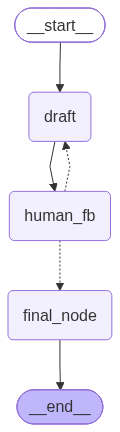

In [103]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [104]:
config={'configurable':{"thread_id":'2'}}

res=graph.invoke({'query':"write a mail to HR asking a 4 days paid leave from september 4-8"},
                 config=config)

res

{'query': 'write a mail to HR asking a 4 days paid leave from september 4-8',
 'draft': 'Here’s a professional and polite email template you can use to request a 4-day paid leave from September 4–8. Adjust the details (like your name, position, and reason for leave) as needed:\n\n---\n\n**Subject:** Request for Paid Leave: September 4–8\n\nDear [HR Manager\'s Name],\n\nI hope this email finds you well. I am writing to formally request a paid leave of absence from **September 4 to September 8, 2024** (4 days).\n\nThe reason for my leave is [briefly state reason, e.g., "personal travel," "family commitments," or "medical appointment"]. I have ensured that my current workload is up to date and will coordinate with [colleague’s name, if applicable] to delegate any urgent tasks during my absence.\n\nPlease let me know if you require any additional details or documentation to process this request. I appreciate your support and will confirm my availability upon my return.\n\nThank you for you

In [105]:
res=graph.invoke(Command(resume="hr name is Isha Niraula and employee name is Biswas bista and organization name is Techspire college"),config=config)
res


{'query': 'write a mail to HR asking a 4 days paid leave from september 4-8',
 'draft': 'Here’s the revised email with the requested details filled in:\n\n---\n\n**Subject:** Request for Paid Leave: September 4–8\n\nDear Isha Niraula,\n\nI hope this email finds you well. I am writing to formally request a paid leave of absence from **September 4 to September 8, 2024** (4 days).\n\nThe reason for my leave is [briefly state reason, e.g., "personal travel," "family commitments," or "medical appointment"]. I have ensured that my current workload is up to date and will coordinate with [colleague’s name, if applicable] to delegate any urgent tasks during my absence.\n\nPlease let me know if you require any additional details or documentation to process this request. I appreciate your support and will confirm my availability upon my return.\n\nThank you for your time and consideration.\n\nBest regards,\nBiswas Bista\n[Your Job Title]\nTechspire College\n\n---',
 'human_feedback': 'hr name is 

In [106]:
print(res['draft'])

Here’s the revised email with the requested details filled in:

---

**Subject:** Request for Paid Leave: September 4–8

Dear Isha Niraula,

I hope this email finds you well. I am writing to formally request a paid leave of absence from **September 4 to September 8, 2024** (4 days).

The reason for my leave is [briefly state reason, e.g., "personal travel," "family commitments," or "medical appointment"]. I have ensured that my current workload is up to date and will coordinate with [colleague’s name, if applicable] to delegate any urgent tasks during my absence.

Please let me know if you require any additional details or documentation to process this request. I appreciate your support and will confirm my availability upon my return.

Thank you for your time and consideration.

Best regards,
Biswas Bista
[Your Job Title]
Techspire College

---
